In [10]:
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import layers, models

env = gym.make('Blackjack-v1')
env.reset()

((18, 2, 0), {})

In [11]:
from collections import deque


class DQN(tf.keras.Model):
    def __init__(self, action_dim):
        super().__init__()
        self.d = models.Sequential(
            [
                layers.Dense(128, activation='relu'),
                layers.Dense(128, activation='relu'),
            ]
        )
        self.out = layers.Dense(action_dim, activation='linear')

    def call(self, x):
        x = self.d(x)
        return self.out(x)


policy_net = DQN(env.action_space.n)
target_net = DQN(env.action_space.n)
dummy_input = tf.zeros((1, 3))
policy_net(dummy_input)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.MeanSquaredError()
gamma = 0.99
batch_size = 64
replay_buffer = deque(maxlen=10000)
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.998
target_update_freq = 200

In [12]:
import random


def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state = tf.expand_dims(tf.convert_to_tensor(state), 0)
        q_values = policy_net(state)
        return tf.argmax(q_values[0]).numpy()



Winrate per 50: 0.27 Epsilon: 0.819, Episode: 100
Winrate per 50: 0.26 Epsilon: 0.670, Episode: 200
Winrate per 50: 0.4 Epsilon: 0.548, Episode: 300
Winrate per 50: 0.3 Epsilon: 0.449, Episode: 400
Winrate per 50: 0.3 Epsilon: 0.368, Episode: 500
Winrate per 50: 0.33 Epsilon: 0.301, Episode: 600
Winrate per 50: 0.37 Epsilon: 0.246, Episode: 700
Winrate per 50: 0.31 Epsilon: 0.202, Episode: 800
Winrate per 50: 0.45 Epsilon: 0.165, Episode: 900
Winrate per 50: 0.32 Epsilon: 0.135, Episode: 1000
Winrate per 50: 0.44 Epsilon: 0.111, Episode: 1100
Winrate per 50: 0.47 Epsilon: 0.091, Episode: 1200
Winrate per 50: 0.45 Epsilon: 0.074, Episode: 1300
Winrate per 50: 0.5 Epsilon: 0.061, Episode: 1400
Winrate per 50: 0.41 Epsilon: 0.050, Episode: 1500
average win rate: 0.372


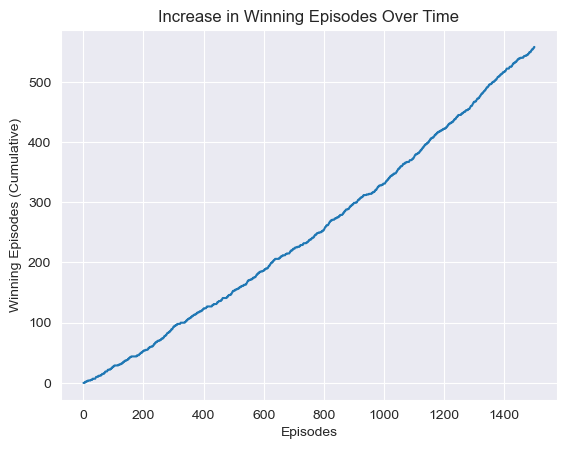

In [13]:
def optimize_model(verbose=False):
    if len(replay_buffer) < batch_size * 8:
        return

    batch = random.sample(replay_buffer, batch_size)
    state_batch, action_batch, reward_batch, next_state_batch, done_batch = zip(*batch)

    state_batch = tf.convert_to_tensor(state_batch, dtype=tf.float32)
    action_batch = tf.convert_to_tensor(action_batch, dtype=tf.int32)
    reward_batch = tf.convert_to_tensor(reward_batch, dtype=tf.float32)
    next_state_batch = tf.convert_to_tensor(next_state_batch, dtype=tf.float32)
    done_batch = tf.convert_to_tensor(done_batch, dtype=tf.float32)

    with tf.GradientTape() as tape:
        q_values_all = policy_net(state_batch)

        action_indices = tf.stack(
            [tf.range(batch_size), action_batch],
            axis=1
        )
        q_values = tf.gather_nd(q_values_all, action_indices)

        max_next_q_values = tf.reduce_max(
            target_net(next_state_batch),
            axis=1
        )

        target_q_values = reward_batch + gamma * max_next_q_values * (1.0 - done_batch)

        loss = tf.keras.losses.MSE(target_q_values, q_values)
        if verbose:
            print(f"Loss: {tf.reduce_mean(loss).numpy()}")

    grads = tape.gradient(loss, policy_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, policy_net.trainable_variables))
    
win_episodes = 0
win_history = []
episode_axis = []
episodes = 1500
steps_done = 0
wins_per_n_games = 0

for episode in range(episodes):
    state = env.reset()[0]
    episode_reward = 0
    done = False

    while not done:
        action = select_action(state, epsilon)
        next_state, reward, done, *_ = env.step(action)

        replay_buffer.append((state, action, reward, next_state, done))
        state = next_state
        episode_reward += reward

        optimize_model()

        if steps_done % target_update_freq == 0:
            target_net.set_weights(policy_net.get_weights())

        steps_done += 1

    epsilon = max(epsilon_min, epsilon_decay * epsilon)

    if episode_reward > 0:
        win_episodes += 1
        wins_per_n_games += 1

    win_history.append(win_episodes)
    episode_axis.append(episode + 1)

    if (episode + 1) % 100 == 0:
        print(f"Winrate per 50: {wins_per_n_games / 100}", f"Epsilon: {epsilon:.3f}, Episode: {episode + 1}")
        wins_per_n_games = 0

import matplotlib.pyplot as plt
print("average win rate:", win_episodes / episodes)
plt.figure()
plt.plot(episode_axis, win_history)
plt.xlabel("Episodes")
plt.ylabel("Winning Episodes (Cumulative)")
plt.title("Increase in Winning Episodes Over Time")
plt.show()
policy_net.save_weights("blackjack_dqn_final.weights.h5")

In [14]:
policy_net = DQN(env.action_space.n)
dummy_input = tf.zeros((1, 3))
policy_net(dummy_input)
policy_net.load_weights('blackjack_dqn_final.weights.h5')
episodes = 500
win_episodes = 0

for episode in range(episodes):
    state = env.reset()[0]
    episode_reward = 0
    done = False

    while not done:
        state = tf.expand_dims(tf.convert_to_tensor(state), 0)
        q_values = policy_net(state)
        action = tf.argmax(q_values[0]).numpy()
        next_state, reward, done, *_ = env.step(action)

        state = next_state
        episode_reward += reward

    if episode_reward > 0:
        win_episodes += 1


print(f"Winrate {win_episodes / episode}")


Winrate 0.42084168336673344
